In [1]:
import torch
import torchvision
import torchvision.transforms as transforms

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True

In [3]:
train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.AutoAugment(transforms.AutoAugmentPolicy.CIFAR10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]
    ),
    transforms.RandomErasing(p=0.5)
])

val_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]
    ),
])

batch_size = 256

full_trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True
)

train_idx, val_idx = torch.utils.data.random_split(
    range(len(full_trainset)), [0.8, 0.2]
)

trainset = torch.utils.data.Subset(
    torchvision.datasets.CIFAR10(root='./data', train=True, transform=train_tf),
    train_idx.indices
)

valset = torch.utils.data.Subset(
    torchvision.datasets.CIFAR10(root='./data', train=True, transform=val_tf),
    val_idx.indices
)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True
)
valloader = torch.utils.data.DataLoader(
    valset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True
)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=val_tf
)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True
)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

C:\Users\asmit\PycharmProjects\TorchT\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


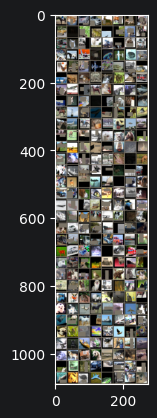

horse cat   car   car   deer  horse frog  cat   car   deer  bird  frog  plane frog  deer  cat   ship  cat   car   deer  truck horse dog   cat   frog  horse plane frog  frog  plane frog  bird  bird  car   car   plane frog  truck truck truck plane frog  cat   frog  cat   frog  deer  truck truck plane plane horse dog   horse dog   car   car   dog   cat   deer  ship  dog   cat   dog   horse ship  bird  plane truck horse horse bird  deer  plane horse deer  horse dog   plane ship  dog   deer  dog   plane dog   dog   horse horse horse horse bird  cat   frog  ship  ship  cat   horse cat   ship  truck deer  frog  truck deer  dog   ship  horse plane cat   deer  ship  truck cat   bird  horse plane ship  dog   ship  dog   car   car   dog   cat   frog  horse plane horse plane truck ship  cat   deer  cat   car   plane frog  deer  cat   dog   plane dog   frog  truck frog  car   dog   ship  ship  ship  car   cat   truck bird  truck cat   car   car   ship  horse deer  car   frog  ship  cat   car   truc

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img * std + mean
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)).clip(0, 1))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [5]:
import torch.nn.functional as F
from torch import nn

In [6]:
class SimpleResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(SimpleResBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
            
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out


In [7]:
class Classifier(nn.Module):
    def __init__(self):
        super(Classifier, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 128, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)

        self.conv3 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)

        self.conv4 = nn.Conv2d(256, 256, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        self.fc1 = nn.Linear(256, 128)
        self.fc2 = nn.Linear(128, 10)
        self.do = nn.Dropout(0.5)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))

        x = nn.AdaptiveAvgPool2d((1, 1))(x)
        x = torch.flatten(x, 1)

        x = self.do(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x


In [8]:
# class Classifier(nn.Module):
#     def __init__(self):
#         super(Classifier, self).__init__()
#         # Initial Convolution
#         self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
#         self.bn1 = nn.BatchNorm2d(64)
#
#         # Residual Blocks
#         self.layer1 = SimpleResBlock(64, 64, stride=1)
#         self.layer2 = SimpleResBlock(64, 128, stride=2)
#         self.layer3 = SimpleResBlock(128, 256, stride=2)
#         self.layer4 = SimpleResBlock(256, 512, stride=2)
#
#         # Global Average Pooling and Classifier
#         self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
#         self.fc = nn.Linear(512, 10)
#
#     def forward(self, x):
#         x = F.relu(self.bn1(self.conv1(x)))
#
#         x = self.layer1(x)
#         x = self.layer2(x)
#         x = self.layer3(x)
#         x = self.layer4(x)
#
#         x = self.avgpool(x)
#         x = torch.flatten(x, 1)
#         x = self.fc(x)
#         return x


In [9]:
classifier = Classifier()

In [10]:
classifier.to(device)

Classifier(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=256, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (do): Dropout(p=0.5, inplace=False)
)

In [11]:
class EarlyStoping:
    def __init__(self, patience=5, min_delta=0.001, verbose=False):
        self.patience = patience
        self.verbose = verbose
        self.best_loss = float('inf')
        self.min_delta = min_delta
        self.counter = 0
        self.early_stop = False

    def __call__(self, loss):
        if loss < self.best_loss - self.min_delta:
            self.best_loss = loss
            self.counter = 0
        else:
            self.counter += 1
            if self.verbose: print(f"EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True


In [12]:
from utils.callbacks import ModelCheckpoint

In [13]:
from torch import optim

In [14]:
criterion = nn.CrossEntropyLoss()
epochs = 80
optimizer = optim.SGD(classifier.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
# OneCycleLR: max_lr=0.1 for SGD
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.1,
    steps_per_epoch=len(trainloader),
    epochs=epochs,
    pct_start=0.3,
    anneal_strategy='cos',
    div_factor=25,
    final_div_factor=1e4
)
# Optimization: AMP Scaler
scaler = torch.amp.GradScaler('cuda')
checkpoint = ModelCheckpoint(classifier, mode='max', verbose=True)

In [15]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            loss = criterion(model(imgs), labels)
            total += loss.item()
    model.train()
    return total / len(loader)

In [16]:
train_losses, val_losses, val_accuracies = [], [], []
import time
epoc_start = time.time()
for epoch in range(epochs):
    classifier.train()
    epoch_loss = 0.0
    n_batches = 0
    start_time = time.time()

    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        # Optimization: Mixed Precision Forward Pass
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            outputs = classifier(inputs)
            loss = criterion(outputs, labels)

        # Optimization: Scaled Backward Pass
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # OneCycleLR MUST step after every mini-batch, not once per epoch
        scheduler.step()

        epoch_loss += loss.item()
        n_batches += 1

    # ─── Per-epoch logging ───────────────────────────────────────────────────
    avg_train_loss = epoch_loss / n_batches
    train_losses.append(avg_train_loss)

    # Validation: loss + accuracy in one pass
    classifier.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, lbls in valloader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                out = classifier(imgs)
            val_loss += criterion(out, lbls).item()
            _, predicted = torch.max(out, 1)
            total += lbls.size(0)
            correct += (predicted == lbls).sum().item()

    avg_val_loss = val_loss / len(valloader)
    val_acc = 100.0 * correct / total
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    checkpoint(val_acc, epoch, optimizer, scheduler, scaler)

    current_lr = scheduler.get_last_lr()[0]
    print(
            f'Epoch [{epoch+1:2d}/{epochs}]  '
            f'Train Loss: {avg_train_loss:.4f}  '
            f'Val Loss: {avg_val_loss:.4f}  '
            f'Val Acc: {val_acc:.2f}%  '
            f'LR: {current_lr:.6f} '
            f'Time: {time.time() - start_time:.2f}s'
          )

checkpoint.restore_best_weights()

print(f"Finished Training in {(time.time() - epoc_start)/60:.2f} minutes")


[ModelCheckpoint] New best (max): 32.3600 — saved to checkpoint\best_model.pth
Epoch [ 1/80]  Train Loss: 2.0919  Val Loss: 1.8067  Val Acc: 32.36%  LR: 0.004411 Time: 15.77s
[ModelCheckpoint] New best (max): 42.8500 — saved to checkpoint\best_model.pth
Epoch [ 2/80]  Train Loss: 1.8256  Val Loss: 1.5375  Val Acc: 42.85%  LR: 0.005636 Time: 4.16s
Epoch [ 3/80]  Train Loss: 1.7092  Val Loss: 1.5474  Val Acc: 41.94%  LR: 0.007656 Time: 4.11s
[ModelCheckpoint] New best (max): 47.1200 — saved to checkpoint\best_model.pth
Epoch [ 4/80]  Train Loss: 1.6216  Val Loss: 1.4394  Val Acc: 47.12%  LR: 0.010434 Time: 4.19s
[ModelCheckpoint] New best (max): 52.1200 — saved to checkpoint\best_model.pth
Epoch [ 5/80]  Train Loss: 1.5457  Val Loss: 1.3052  Val Acc: 52.12%  LR: 0.013924 Time: 4.81s
[ModelCheckpoint] New best (max): 54.4400 — saved to checkpoint\best_model.pth
Epoch [ 6/80]  Train Loss: 1.5027  Val Loss: 1.2612  Val Acc: 54.44%  LR: 0.018066 Time: 4.11s
[ModelCheckpoint] New best (max): 

In [25]:
PATH = './cifar_net_.pth'
# torch.save(classifier.state_dict(), PATH)

In [26]:
torch.load(PATH, weights_only=True)

OrderedDict([('conv1.weight',
              tensor([[[[ 2.4273e-01, -4.8077e-01, -2.5931e-01],
                        [ 2.8870e-01,  7.4368e-02,  1.5225e-01],
                        [-1.3322e-02, -5.7124e-03,  2.1050e-02]],
              
                       [[-2.4642e-01, -5.6010e-01,  4.3869e-02],
                        [-1.3781e-01,  8.4759e-02,  5.4603e-01],
                        [-2.4529e-01,  1.3720e-01,  4.1744e-01]],
              
                       [[ 5.1584e-01, -1.4031e-01, -2.3138e-01],
                        [ 5.1930e-01,  5.7936e-02, -1.4988e-01],
                        [-7.7020e-02, -2.1125e-01, -3.4832e-01]]],
              
              
                      [[[-3.4601e-02, -3.5743e-02,  6.0755e-02],
                        [ 2.2832e-01, -8.6998e-03, -1.5567e-01],
                        [-2.5918e-01,  7.0747e-02,  1.1262e-01]],
              
                       [[-4.0704e-02, -1.0681e-01,  9.0844e-02],
                        [ 2.0791e-01, -8.8898

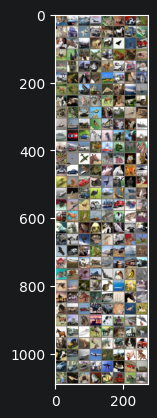

GroundTruth:  cat   ship  ship  plane


In [27]:
dataiter = iter(testloader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

# print images
imshow(torchvision.utils.make_grid(images.to('cpu')))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

In [28]:
clsifer = Classifier()
clsifer.load_state_dict(torch.load(PATH, weights_only=True))
clsifer.to(device)
clsifer.eval()

Classifier(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=256, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (do): Dropout(p=0.5, inplace=False)
)

In [29]:
outputs = clsifer(images)

In [30]:
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}' for j in range(4)))

Predicted:  cat   ship  ship  plane


In [31]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        # calculate outputs by running images through the network
        outputs = clsifer(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 90 %


In [24]:
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        outputs = clsifer(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 92.3 %
Accuracy for class: car   is 95.4 %
Accuracy for class: bird  is 84.8 %
Accuracy for class: cat   is 77.7 %
Accuracy for class: deer  is 91.6 %
Accuracy for class: dog   is 83.3 %
Accuracy for class: frog  is 93.5 %
Accuracy for class: horse is 91.9 %
Accuracy for class: ship  is 93.8 %
Accuracy for class: truck is 94.8 %
